# Predictive Maintenance Using Machine Learning
### Early Detection of Machine Failures Using Sensor Data

**Author:** Kevin Danh  
**Objective:** Predict rare machine failures using sensor data to enable proactive maintenance and reduce downtime.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score, average_precision_score, precision_recall_curve

In [2]:
# Load the data
df = pd.read_csv("predictive_maintenance_dataset.csv")
df.head()

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,1/1/2015,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,1/1/2015,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,1/1/2015,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,1/1/2015,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,1/1/2015,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


## Problem Statement

In industrial systems, machine failures are rare but extremely costly. 
This dataset contains highly imbalanced sensor readings, where failure events represent less than 0.1% of all observations.

The goal of this project is to build a machine learning model that can detect early warning signs of failure.

In [3]:
# Check quick summary of statistics
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124494 entries, 0 to 124493
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   date     124494 non-null  object
 1   device   124494 non-null  object
 2   failure  124494 non-null  int64 
 3   metric1  124494 non-null  int64 
 4   metric2  124494 non-null  int64 
 5   metric3  124494 non-null  int64 
 6   metric4  124494 non-null  int64 
 7   metric5  124494 non-null  int64 
 8   metric6  124494 non-null  int64 
 9   metric7  124494 non-null  int64 
 10  metric8  124494 non-null  int64 
 11  metric9  124494 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 11.4+ MB
None
             failure       metric1        metric2        metric3  \
count  124494.000000  1.244940e+05  124494.000000  124494.000000   
mean        0.000851  1.223881e+08     159.492706       9.940897   
std         0.029167  7.045933e+07    2179.677781     185.748131   
min         0.000000  0.0000

In [4]:
# Check missing values
print(df.isnull().sum())

date       0
device     0
failure    0
metric1    0
metric2    0
metric3    0
metric4    0
metric5    0
metric6    0
metric7    0
metric8    0
metric9    0
dtype: int64


In [5]:
# Check count of unique values
print(df.nunique())

date          304
device       1169
failure         2
metric1    123877
metric2       560
metric3        48
metric4       115
metric5        60
metric6     44838
metric7        28
metric8        28
metric9        67
dtype: int64


In [6]:
# Check class balance
print(df['failure'].value_counts())

failure
0    124388
1       106
Name: count, dtype: int64


## Data Overview

The dataset contains sensor readings from industrial machines, including:
- 9 numerical sensor metrics
- Device identifiers
- Timestamp information
- Binary failure indicator (target variable)

The dataset is highly imbalanced, which presents a significant modeling challenge.

In [7]:
# Fix the data object into proper datetime format/data type
df['date'] = pd.to_datetime(df['date'])

df.head(5)

,date,device,failure,metric1,metric2,metric3,metric4,metric5,metric6,metric7,metric8,metric9
0,2015-01-01,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,2015-01-01,S1F0166B,0,61370680,0,3,0,6,403174,0,0,0
2,2015-01-01,S1F01E6Y,0,173295968,0,0,0,12,237394,0,0,0
3,2015-01-01,S1F01JE0,0,79694024,0,0,0,6,410186,0,0,0
4,2015-01-01,S1F01R2B,0,135970480,0,0,0,15,313173,0,0,3


## Feature Engineering

To capture temporal dependencies in machine behavior, lag and rolling features were created at the device level:

- Lag features capture previous sensor readings
- Rolling averages smooth short-term fluctuations

These features help the model detect patterns leading up to failures.

In [8]:
# Create lag features over previous day values
for col in ['metric1','metric2','metric3','metric4','metric5','metric6','metric7','metric8','metric9']:
    df[f'{col}_lag1'] = df.groupby('device')[col].shift(1)

In [9]:
# Create rolling averages over the last 3 days' values
for col in ['metric1','metric2','metric3','metric4','metric5','metric6','metric7','metric8','metric9']:
    df[f'{col}_roll3'] = df.groupby('device')[col].rolling(3).mean().reset_index(0, drop=True)

In [10]:
# Drop any created rows that contained null
df_new = df.copy().dropna()

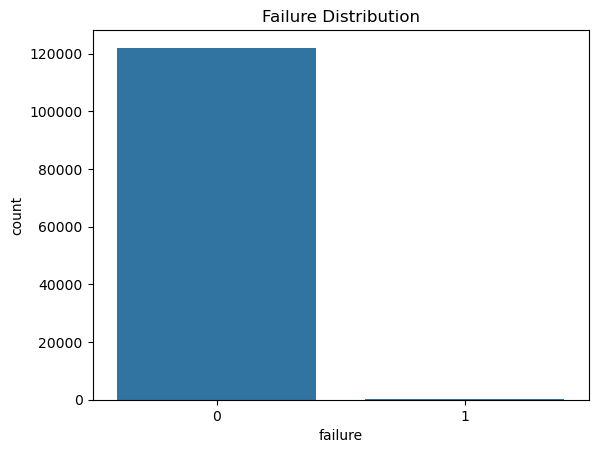

In [11]:
# Visualize the failure distribution
sns.countplot(x='failure', data=df_new)
plt.title("Failure Distribution")
plt.show()

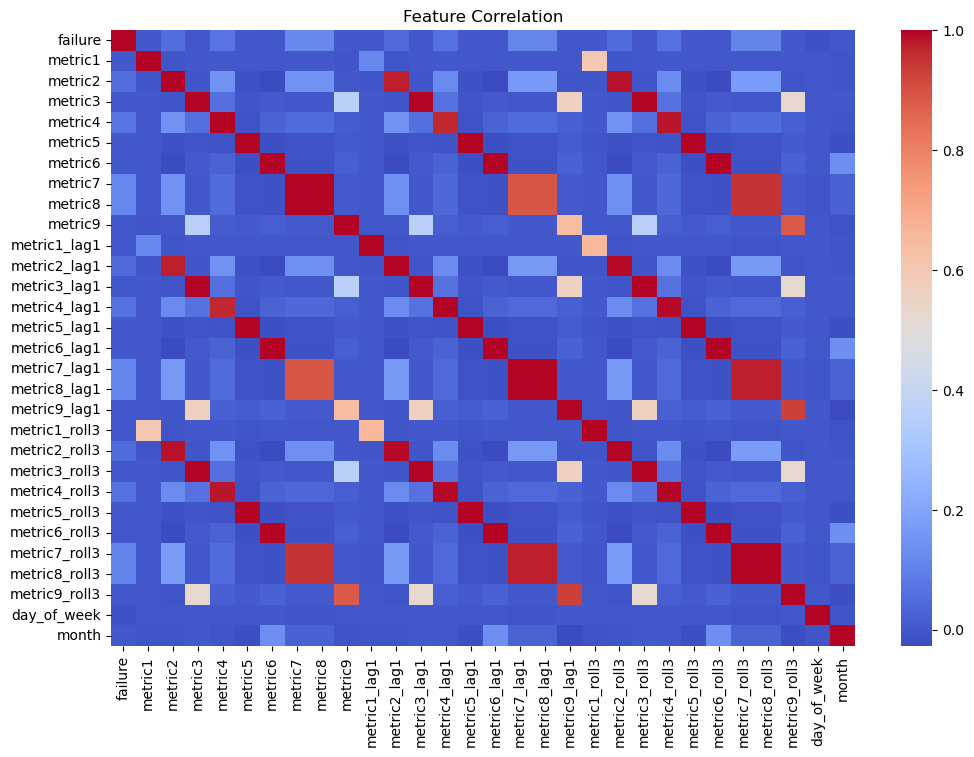

In [12]:
# Visualize any potential correlation
df_new['day_of_week'] = df_new['date'].dt.dayofweek
df_new['month'] = df_new['date'].dt.month

df_new.drop(columns=['date', 'device'], inplace=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_new.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

The device identifier was excluded from the predictive model due to its high cardinality and lack of direct relationship to failure. Including this feature could lead to overfitting and reduce the model’s ability to generalize to unseen devices. However, it was used during feature engineering to generate time-based features such as lag variables and rolling averages.

The raw date variable was also excluded from the model because it does not provide meaningful numerical information. Instead, time-based features such as day of the week and month were extracted to capture potential temporal patterns in device behavior.

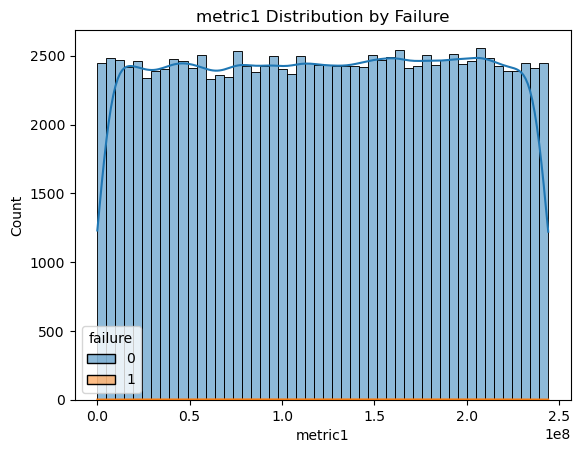

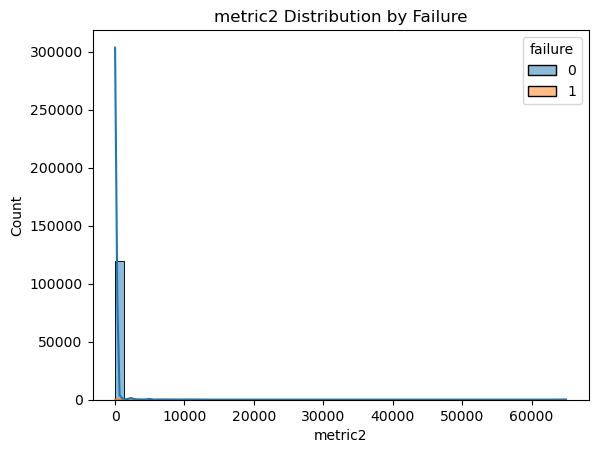

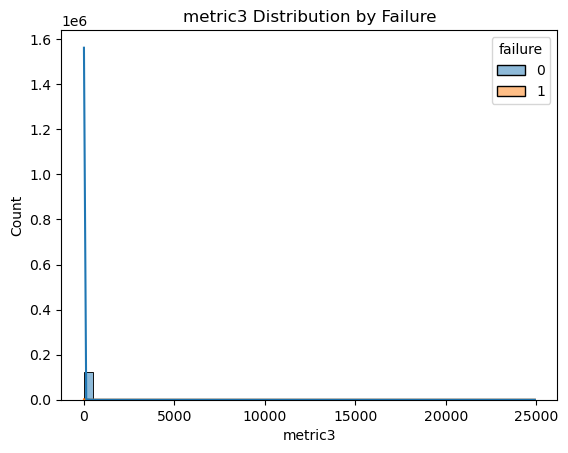

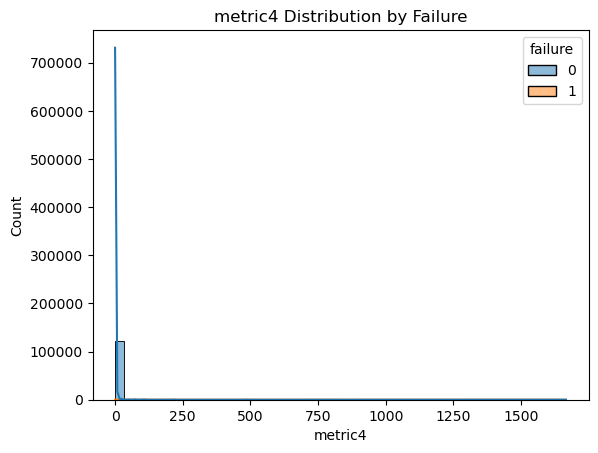

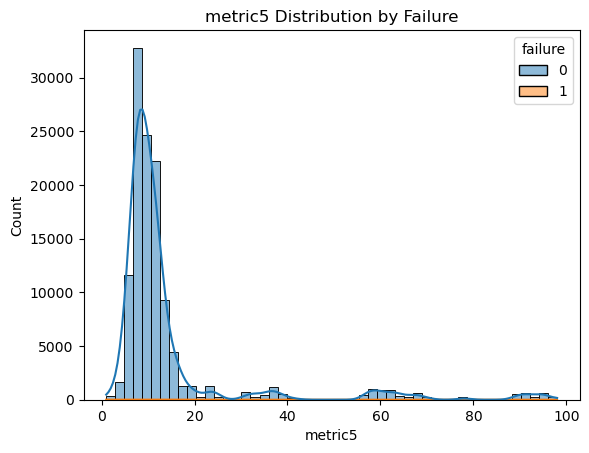

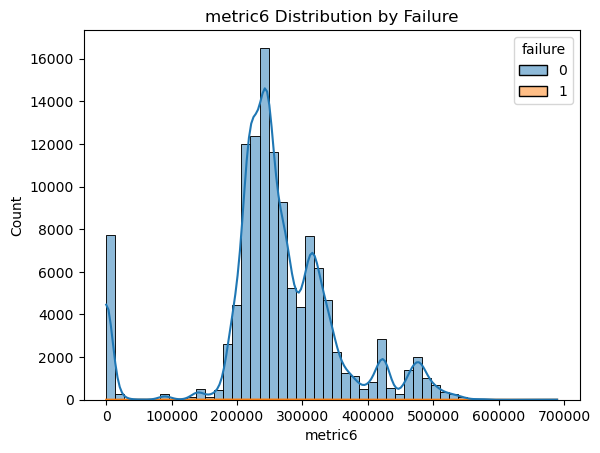

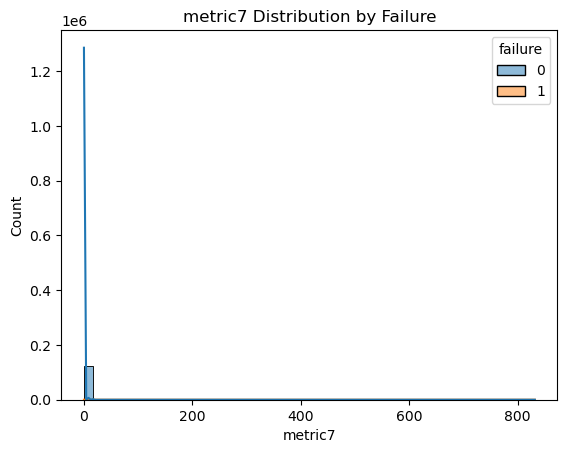

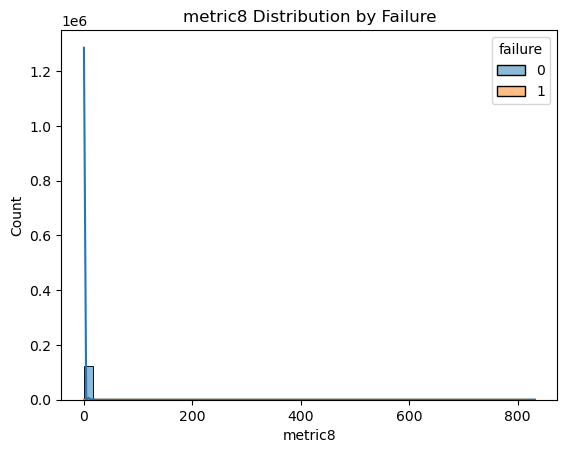

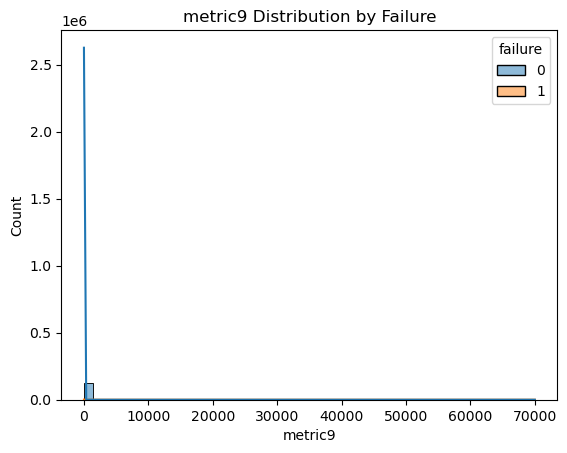

In [13]:
# Check for potential skews for all metrics
metrics = [f'metric{i}' for i in range(1,10)]

for col in metrics:
    plt.figure()
    sns.histplot(data=df_new, x=col, hue='failure', bins=50, kde=True)
    plt.title(f"{col} Distribution by Failure")
    plt.show()

## Handling Skewed Distributions

Distribution analysis of sensor metrics revealed differences between normal operation and failure conditions. Several metrics exhibited skewness and variation prior to failure events, suggesting their importance in predicting device failure.
Several sensor metrics exhibited heavy right-skewed distributions. 
A log transformation (log1p) was applied to stabilize variance and improve model performance.



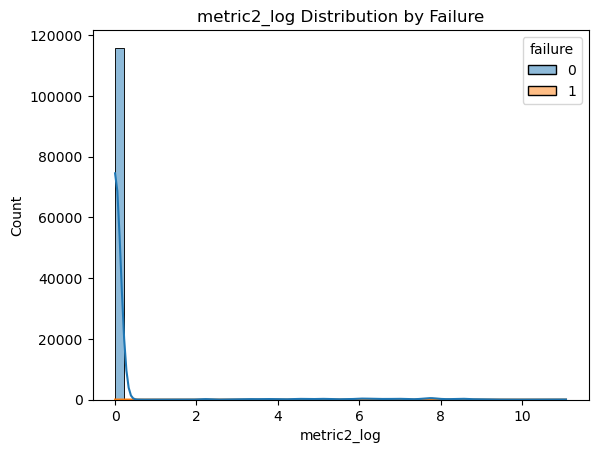

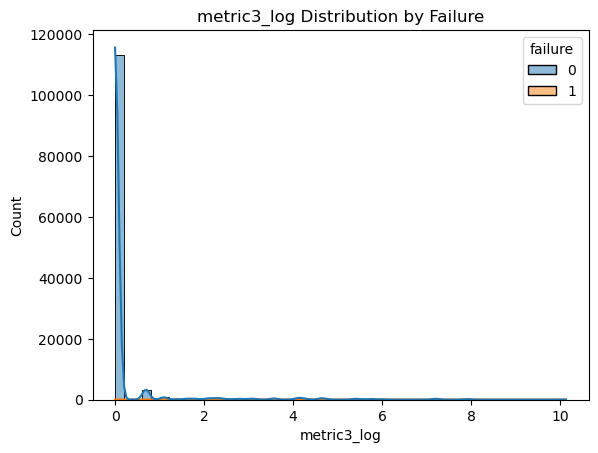

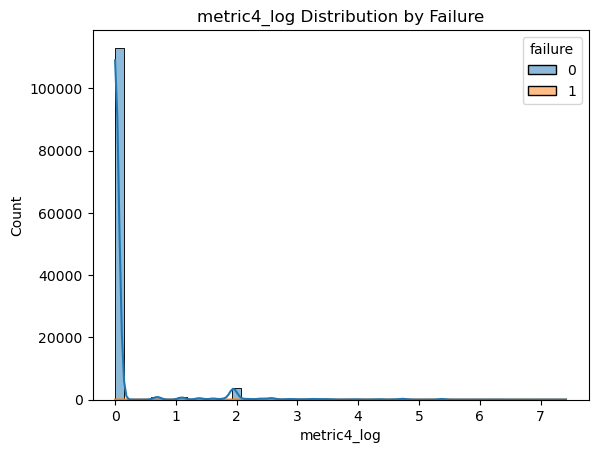

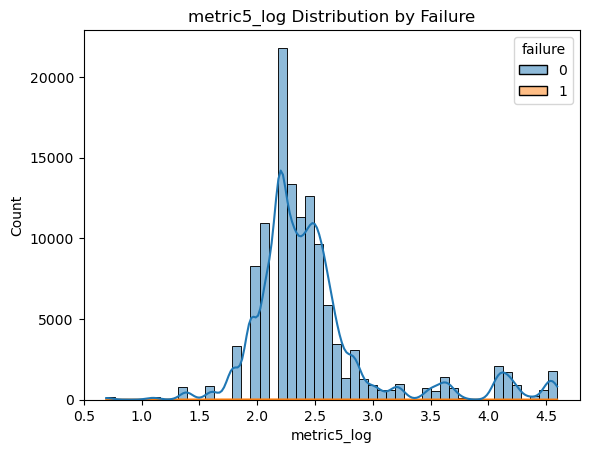

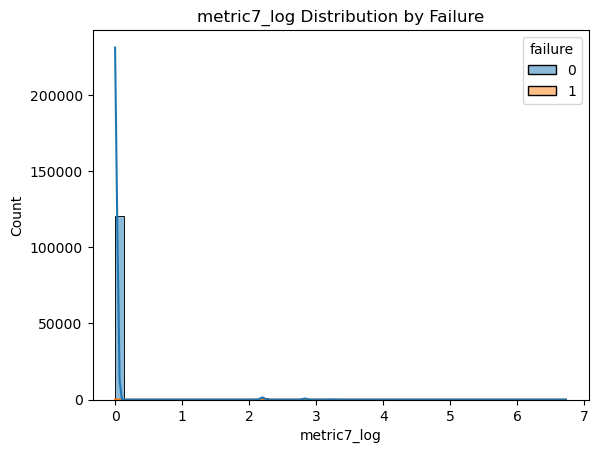

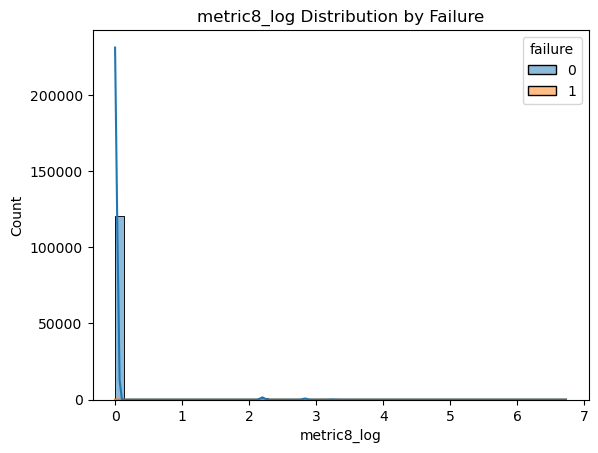

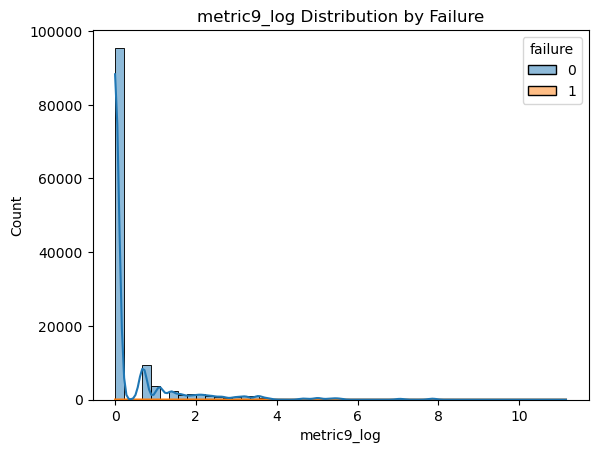

In [14]:
# Log transform the highly skewed metrics
metrics = ['metric2', 'metric3', 'metric4', 'metric5', 'metric7', 'metric8', 'metric9']

for col in metrics:
    df_new[f'{col}_log'] = np.log1p(df_new[col])

for col in metrics:
    plt.figure()
    sns.histplot(data=df_new, x=f'{col}_log', hue='failure', bins=50, kde=True)
    plt.title(f"{col}_log Distribution by Failure")
    plt.show()

# Drop the unmodified metrics for training and splitting
df_new.drop(columns=metrics, inplace=True)

Even after applying a logarithmic transformation, several metrics remained highly skewed, with a concentration of values near zero and a long right tail. Additionally, there was significant overlap between failure and non-failure cases, suggesting that these metrics alone are not a strong predictor. However, it may still contribute to model performance when combined with other features and temporal patterns.

In [15]:
# Split the data for modeling
X = df_new.drop(columns='failure')
y = df_new['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

## Model Selection

Three machine learning models were evaluated:
- Logistic Regression (baseline model)
- Random Forest (non-linear ensemble model)
- XGBoost (gradient boosting model)

Models were compared using ROC-AUC, PR-AUC, recall, and confusion matrices.

In [16]:
# Train the baseline model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [17]:
# Train the random forest model
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=0)

In [18]:
# Train the XGBoost model
xgb = XGBClassifier(eval_metric='aucpr', random_state=0, scale_pos_weight=1173, n_jobs=-1) # scale_pos_weight value = 124388 / 106 of 0:1 ratio from failure target
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

In [19]:
# Evaluate the following models used
def evaluate(model, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("PR-AUC:", average_precision_score(y_test, y_prob))

print("--------Logistic Regression--------")
evaluate(lr)

print("\n--------Random Forest--------")
evaluate(rf)

print("\n--------XGBoost--------")
evaluate(xgb)

--------Logistic Regression--------
Confusion Matrix:
[[23165  1246]
 [   14     7]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     24411
           1       0.01      0.33      0.01        21

    accuracy                           0.95     24432
   macro avg       0.50      0.64      0.49     24432
weighted avg       1.00      0.95      0.97     24432

ROC-AUC: 0.6797774617609939
PR-AUC: 0.004113315589671047

--------Random Forest--------
Confusion Matrix:
[[24410     1]
 [   21     0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24411
           1       0.00      0.00      0.00        21

    accuracy                           1.00     24432
   macro avg       0.50      0.50      0.50     24432
weighted avg       1.00      1.00      1.00     24432

ROC-AUC: 0.7068437140945436
PR-AUC: 0.0221347657191756

--------XGBoost-----

## Note on Evaluation Metric

Accuracy is not a reliable metric for this dataset due to extreme class imbalance 
(~1173:1 ratio between normal and failure cases). Therefore, evaluation focuses on:
- Recall (failure detection rate)
- Precision-Recall tradeoff
- ROC-AUC and PR-AUC

## Precision-Recall Curve

The Precision-Recall curve visualizes the tradeoff between precision and recall across different decision thresholds. This is especially important for imbalanced datasets, where performance on the minority class is critical.

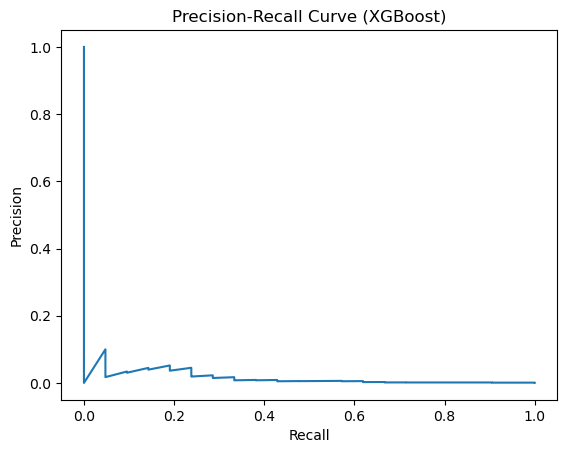

In [20]:
# Use XGBoost probabilities
y_prob = xgb.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost)")
plt.show()

## Precision-Recall Curve Interpretation

The Precision-Recall curve shows that the model achieves high precision at very low recall levels, indicating that it can confidently identify a small subset of failure cases.

However, precision decreases rapidly as recall increases, meaning that capturing more failures leads to a higher number of false positives. This reflects the difficulty of the problem, as failure events are extremely rare and overlap significantly with normal operating conditions.

This tradeoff highlights the importance of selecting an appropriate decision threshold based on operational requirements.

## Why PR-AUC is Important in This Problem

Due to extreme class imbalance (~0.085% positive class), ROC-AUC alone can be misleading because it does not reflect performance on the minority class. PR-AUC provides a more realistic evaluation of the model's ability to detect rare failure events. Therefore, PR-AUC is used alongside ROC-AUC when comparing models.

## Final Model Selection

After evaluating all models, XGBoost was selected as the final model because it provided the strongest overall ranking performance and the most practical foundation for threshold optimization. Although Random Forest achieved a slightly higher PR-AUC under the default threshold, it failed to identify any failure cases, making it unsuitable for predictive maintenance in practice.

Logistic Regression achieved higher recall but produced a large number of false positives, indicating unstable predictions. Random Forest achieved relatively higher PR-AUC but failed to detect any failure cases at the default threshold.

XGBoost provided the best balance between ranking performance and practical usability, making it the most suitable model for threshold tuning and deployment.

- Logistic Regression: higher recall but unstable predictions
- Random Forest: achieved relatively higher PR-AUC but failed to detect any failure events under the default threshold, making it unsuitable without further tuning
- XGBoost: best overall discrimination ability (ROC-AUC ≈ 0.76)

Therefore, XGBoost was selected as the final modeling approach.

## Cross-Validation (Model Stability)

To ensure the model performance is stable and not dependent on a single train-test split, Stratified K-Fold cross-validation is used. This maintains the class imbalance distribution across folds and provides a more reliable estimate of model performance.

In [21]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring='average_precision'  # PR-AUC
)

print("PR-AUC CV Scores:", cv_scores)
print("Mean PR-AUC:", cv_scores.mean())

PR-AUC CV Scores: [0.01340641 0.08645896 0.01027159 0.02803811 0.00628304]
Mean PR-AUC: 0.028891623353695772


## Cross-Validation Results

The XGBoost model was evaluated using Stratified K-Fold cross-validation with PR-AUC as the scoring metric.

The mean PR-AUC across folds was 0.0289, which is significantly higher than the baseline failure rate (~0.00085), indicating that the model is able to learn meaningful patterns associated with machine failure.

However, variability across folds was observed, with PR-AUC ranging from 0.006 to 0.086. This is expected due to the extremely small number of failure cases and reflects the inherent difficulty of predicting rare events.

Overall, the results suggest that the model generalizes reasonably well, but performance is sensitive to the distribution of failure cases in the data.

## Threshold Optimization

After confirming model stability through cross-validation, the decision threshold is adjusted to prioritize recall. In predictive maintenance, missing a failure is more costly than false positives, so a lower threshold is selected to increase sensitivity. The default threshold of 0.5 was too conservative for this rare-event detection problem. A lower threshold was selected to increase recall, since missing machine failures is more costly than generating additional false alarms.

In [22]:
# Maximize recall on best model
y_prob = xgb.predict_proba(X_test)[:, 1]
best_t = 0
best_recall = 0

for t in np.arange(0.01, 0.51, 0.01):
    y_pred = (y_prob >= t).astype(int)
    score = recall_score(y_test, y_pred)

    if score > best_recall:
        best_recall = score
        best_t = t

print("Best Threshold:", best_t)
print("Best Recall:", best_recall)

Best Threshold: 0.01
Best Recall: 0.23809523809523808


The optimal threshold identified in this analysis was 0.01, which increased recall to 0.24. This threshold was selected because it better aligns model behavior with the predictive maintenance objective of catching failures early.

In [23]:
y_pred = (y_prob >= best_t).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("PR-AUC:", average_precision_score(y_test, y_prob))

Confusion Matrix:
[[24263   148]
 [   16     5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24411
           1       0.03      0.24      0.06        21

    accuracy                           0.99     24432
   macro avg       0.52      0.62      0.53     24432
weighted avg       1.00      0.99      1.00     24432

ROC-AUC: 0.7628586644194362
PR-AUC: 0.017501230626883746


## Final Model Results

The XGBoost model was selected as the final model due to its strong ranking performance (ROC-AUC ≈ 0.76, PR-AUC ≈ 0.0175).

Due to extreme class imbalance, the decision threshold was optimized (0.01) to prioritize recall over precision.

Final performance shows that the model can successfully identify a portion of rare machine failures, which is critical for predictive maintenance systems where missed failures are more costly than false alarms.

## Feature Importance

Understanding which features contribute most to predictions helps interpret the model. Feature importance from XGBoost highlights which sensor metrics and engineered features are most influential in predicting machine failure.

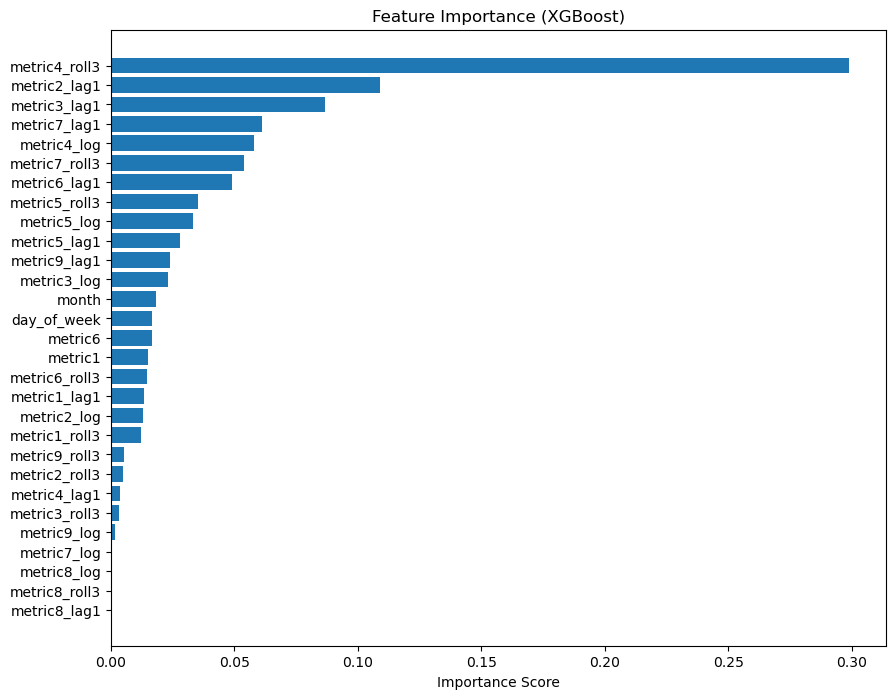

In [24]:
importances = xgb.feature_importances_
features = X.columns

# Sort for better visualization
indices = np.argsort(importances)

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

The feature importance plot shows that both raw sensor values and engineered temporal features contribute to failure prediction. This suggests that failure risk is influenced not only by the current sensor state, but also by recent changes in machine behavior over time. The most important features in the XGBoost model were `metric4_roll3`, `metric2_lag1`, and `metric3_lag1`. This indicates that recent historical patterns in these sensor metrics may provide useful early warning signals prior to machine failure.

## Model Tradeoffs

Due to the rarity of failure events, there is a tradeoff between precision and recall. The final model prioritizes recall, meaning it is more likely to detect failures at the cost of increased false positives.

In predictive maintenance, this tradeoff is acceptable because missing a failure is typically more costly than performing unnecessary maintenance.

## Business Impact

This model can be used in industrial environments to:
- Detect early warning signs of machine failure
- Reduce unexpected downtime
- Enable proactive maintenance scheduling
- Improve operational efficiency

Even partial detection of failures can significantly reduce maintenance costs and prevent equipment damage.

## Deployment Considerations

In a production environment, this model could be applied to continuously collected sensor data and used to generate failure risk scores at regular intervals. Alerts could be triggered when predicted risk exceeds the chosen threshold, enabling maintenance teams to inspect equipment before a breakdown occurs.

## Limitations
Because the data was split randomly rather than by time, future iterations should evaluate the model using time-based validation to better reflect real-world deployment conditions and reduce the risk of temporal leakage.

- Extreme class imbalance limits recall performance
- Low number of failure samples reduces model generalization
- Sensor data may contain hidden noise or unmeasured variables

## Future Improvements

- Collect more failure data to improve model learning
- Experiment with anomaly detection methods (Isolation Forest, Autoencoders)
- Deploy real-time monitoring system for live predictions